<a href="https://colab.research.google.com/github/ClaudioRo81/Data_Scientist/blob/main/PCA_and_Clusters_organizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 4 - PCA + K means del dataset Big Five (IPIP-50)

**CLAUDIO ROJAS DURAN**

**Datos:** `Big5raw.csv` (respuestas crudas de un test de personalidad de 50 items, c. 2012)

**Codebook:** `codebook.txt`

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Para los colores etc...
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns",60)

## 2. Carga de archivos

In [2]:
df = pd.read_csv("Big5raw.csv")
print("Dimensiones originales", df.shape)
df.head()

Dimensiones originales (19726, 57)


,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10,race,age,engnat,gender,hand,source,country
0,4,2,5,2,5,1,4,3,5,1,1,5,2,5,1,1,1,1,1,1,1,5,1,5,2,3,1,5,4,5,4,1,5,1,5,1,4,1,4,5,4,1,3,1,5,1,4,2,5,5,3,53.0,1.0,1,1,1,US
1,2,2,3,3,3,3,1,5,1,5,2,3,4,2,3,4,3,2,2,4,1,3,3,4,4,4,2,3,4,3,4,1,3,2,3,1,5,1,4,4,3,3,3,3,2,3,3,1,3,2,13,46.0,1.0,2,1,1,US
2,5,1,1,4,5,1,1,5,5,1,5,1,5,5,5,5,5,5,5,5,5,1,5,5,1,5,1,5,5,5,4,1,5,1,5,1,5,1,5,5,4,5,5,1,5,1,5,5,5,5,1,14.0,2.0,2,1,1,PK
3,2,5,2,4,3,4,3,4,4,5,5,4,4,2,4,5,5,5,4,5,2,5,4,4,3,5,3,4,4,3,3,3,4,5,1,4,5,4,2,3,4,3,5,2,4,2,5,2,5,5,3,19.0,2.0,2,1,1,RO
4,3,1,3,3,3,1,3,1,3,5,3,3,3,4,3,3,3,3,3,4,5,5,3,5,1,5,1,5,5,5,3,1,5,3,3,1,1,3,3,3,3,1,1,1,3,1,3,1,5,3,11,25.0,2.0,2,1,2,US


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19726 entries, 0 to 19725
Data columns (total 57 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   E1       19726 non-null  int64  
 1   E2       19726 non-null  int64  
 2   E3       19726 non-null  int64  
 3   E4       19726 non-null  int64  
 4   E5       19726 non-null  int64  
 5   E6       19726 non-null  int64  
 6   E7       19726 non-null  int64  
 7   E8       19726 non-null  int64  
 8   E9       19726 non-null  int64  
 9   E10      19726 non-null  int64  
 10  N1       19726 non-null  int64  
 11  N2       19726 non-null  int64  
 12  N3       19726 non-null  int64  
 13  N4       19726 non-null  int64  
 14  N5       19726 non-null  int64  
 15  N6       19726 non-null  int64  
 16  N7       19726 non-null  int64  
 17  N8       19726 non-null  int64  
 18  N9       19726 non-null  int64  
 19  N10      19726 non-null  int64  
 20  A1       19726 non-null  int64  
 21  A2       197

## 3. Análisis de variables

- **50 items:** (`E1,...E10`,`N1,...N10`,`A1,...A10`,`C1,...C10`,`O1,...O10`)
Cada bloque de 10 items corresponde a un rango de personalidad, donde:

  - **E** = Extraversión
  - **N** = Neuroticismo
  - **A** = Amabilidad
  - **C** = Responsabilidad
  - **O** = Apertura a la experiencia

- **Demograficas:**
  - `race` 1 - 13 , 0 = missed
  - `age` texto libre, menor a 13 no se registra
  - `engnat` 1=si / 2=no / 0=missed
  - `gender` 1=Hombre / 2=Mujer / 3=Otro, 0=missed
  - `hand` 1=derecha / 2=Izquierda / 3=Ambas / 0=Missed

- **Tecnicas:**
  - `country` código ISO del pais
  - `source` comó llegó al test




### 3.1 ¿Por qué invertir algunos ítems antes de promediar?

Cada rasgo se mide con 10 frases, pero no todas apuntan en la misma dirección del rasgo. Por ejemplo, para Extraversión:
- *"I am the life of the party"* (E1): responder "Muy de acuerdo" (5) indica **más** extraversión → ítem **positivo**.
- *"I don't talk a lot"* (E2): responder "Muy de acuerdo" (5) en realidad indica **menos** extraversión, porque la frase está redactada al revés → ítem **negativo**.

Si promediáramos los 10 ítems tal cual, una persona muy extrovertida que responde "Muy de acuerdo" tanto en E1 como en E2 (coherentemente, ya que de verdad "no habla mucho" le describe... o no) generaría un promedio sin sentido, porque E1 sumaría a favor de la extraversión y E2 también sumaría (cuando debería restar). Los pasos para resolverlo son:

1. **Leer las 50 frases del codebook** y, para cada una, preguntarse: *si alguien responde 5 (Muy de acuerdo), ¿eso suma o resta al rasgo?*
2. **Clasificar cada frase** como positiva (suma) o negativa (resta). Por ejemplo, en Amabilidad, *"I feel little concern for others"* (A1) es negativa, mientras que *"I am interested in people"* (A2) es positiva.
3. **Juntar los códigos de todas las frases negativas** de los 5 rasgos en un solo conjunto: `E2,E4,E6,E8,E10` (Extraversión), `N2,N4` (Neuroticismo), `A1,A3,A5,A7` (Amabilidad), `C2,C4,C6,C8` (Responsabilidad), `O2,O4,O6`.
4. **Invertir la escala de los items que esten alreves**, antes de promediar, con la fórmula estándar para una escala 1–5: `nueva_respuesta = 6 - respuesta_original` (un 1 se vuelve 5, un 5 se vuelve 1). Así, después de invertir, un puntaje alto en *cualquier* ítem de un rasgo significa siempre lo mismo: "más" de ese rasgo. Esta inversión la aplicaremos más adelante, justo antes de calcular los promedios.

In [4]:
item_cols = [f"{t}{i}" for t in ["E","N","A","C","O"] for i in range(1,11)] #Con esto generamos la lista de los 50 nombres de las columnas de los items
demo_cat_cols = ["race","engnat","gender","hand"]   # categóricas, 0 = missed según el codebook
demo_cols = ["race","age","engnat","gender","hand","source","country"]

# Ítems redactados en sentido inverso (según el codebook), a invertir en escala 1-5
reverse_items = {"E2","E4","E6","E8","E10","N2","N4","A1","A3","A5","A7","C2","C4","C6","C8","O2","O4","O6",}
print(f"{len(item_cols)} ítems | {len(reverse_items)} ítems en sentido inverso")

50 ítems | 18 ítems en sentido inverso


## 4. Proceso de limpieza de datos

Aplicaremos las siguientes acciones en caso de detectar valores raros o sin valor:

1. **Valores faltantes en los atributos:** Se eliminara cualquier caso que tenga un 0 en al menos uno de los 50 ítems.
2. **Edades mayores a 65 años:** Se elimina cualquier caso con `age > 65`. Esto también descarta de paso los valores de edad claramente corruptos del archivo original (por ejemplo, participantes con edad capturada como año — 1998, 1999 — o valores absurdos como mil millones), ya que todos ellos son `> 65`.
3. **Codigos de pais ivalidos:** `country` debe ser un código ISO de 2 letras; se elimina cualquier caso cuyo código no cumpla ese formato.
4. **Valores faltantes en las variables demográficas** (`race`, `age`, `engnat`, `gender`, `hand`): el codebook marca `0 = missed` para las categóricas, pero el archivo además contiene códigos que no existen en ningún catálogo del codebook (p. ej. `gender = 20/99`, `race = 3000`, `hand = 10/20`). Tratamos esos códigos igual que un valor faltante, ya que no corresponden a ninguna respuesta válida, y también eliminamos el caso con `age` vacío.

In [5]:
df_clean = df.copy()
n_inicial = len(df_clean)
log = []

CURRENT_YEAR = 2026  # año actual,lo usaremos para calcular la edad a partir de año de nacimiento

# Paso 1: valores faltantes (0) en los atributos (ítems de personalidad)
mask1 = (df_clean[item_cols] == 0).any(axis=1)
n1 = int(mask1.sum())
df_clean = df_clean[~mask1]
log.append(["Valores faltantes en los ítems de personalidad", n1, len(df_clean)])

# Paso 2: recalcular edad cuando se capturó por error como año de nacimiento (p. ej. 1998)
# Se consideran años de nacimiento posibles los valores entre 1900 y (año actual - 13),
# ya que el codebook indica que edades menores a 13 no se registraban.
is_birth_year = (df_clean["age"] >= 1900) & (df_clean["age"] <= CURRENT_YEAR - 13)
n_recalc = int(is_birth_year.sum())
df_clean.loc[is_birth_year, "age"] = CURRENT_YEAR - df_clean.loc[is_birth_year, "age"]
print(f"Edades recalculadas a partir de un año de nacimiento (p. ej. 1998 -> {CURRENT_YEAR - 1998} años): {n_recalc} casos")

# Paso 3: edad mayor a 65 (tras recalcular los años de nacimiento)
mask3 = df_clean["age"] > 65
n3 = int(mask3.sum())
df_clean = df_clean[~mask3]
log.append(["Edad mayor a 65 años", n3, len(df_clean)])

# Paso 4: código de país inválido (no es un ISO de 2 letras)
mask4 = ~df_clean["country"].astype(str).str.fullmatch(r"[A-Za-z]{2}")
n4 = int(mask4.sum())
df_clean = df_clean[~mask4]
log.append(["Código de país inválido (no ISO de 2 letras)", n4, len(df_clean)])

# Paso 5: valores faltantes/inválidos en variables demográficas (race, age, engnat, gender, hand)
valid_race   = set(range(1, 14))
valid_engnat = {1, 2}
valid_gender = {1, 2, 3}
valid_hand   = {1, 2, 3}

mask5 = (
    ~df_clean["race"].isin(valid_race)
    | df_clean["age"].isna()
    | ~df_clean["engnat"].isin(valid_engnat)
    | ~df_clean["gender"].isin(valid_gender)
    | ~df_clean["hand"].isin(valid_hand)
)
n5 = int(mask5.sum())
df_clean = df_clean[~mask5]
log.append(["Valores faltantes/inválidos en variables demográficas", n5, len(df_clean)])

resumen_limpieza = pd.DataFrame(log, columns=["Criterio de limpieza", "Registros eliminados", "Registros restantes"])
resumen_limpieza

Edades recalculadas a partir de un año de nacimiento (p. ej. 1998 -> 28 años): 73 casos


,Criterio de limpieza,Registros eliminados,Registros restantes
0,Valores faltantes en los ítems de personalidad,12,19714
1,Edad mayor a 65 años,143,19571
2,Código de país inválido (no ISO de 2 letras),398,19173
3,Valores faltantes/inválidos en variables demog...,331,18842


In [6]:
print(f"Registros iniciales: {n_inicial}")
print(f"Total de registros eliminados: {n_inicial - len(df_clean)}")
print(f"Total de registros finales: {len(df_clean)}")

# Verificación: no deberían quedar valores faltantes/inválidos en items ni variables demográficas
assert (df_clean[item_cols] == 0).sum().sum() == 0
assert df_clean["age"].isna().sum() == 0 and (df_clean["age"] > 65).sum() == 0
assert df_clean["country"].astype(str).str.fullmatch(r"[A-Za-z]{2}").all()
assert df_clean["race"].isin(valid_race).all() and df_clean["engnat"].isin(valid_engnat).all()
assert df_clean["gender"].isin(valid_gender).all() and df_clean["hand"].isin(valid_hand).all()
print("\nNo quedan valores faltantes/inválidos en los criterios aplicados.")

Registros iniciales: 19726
Total de registros eliminados: 884
Total de registros finales: 18842

No quedan valores faltantes/inválidos en los criterios aplicados.


## 5. Construcción de los puntajes de personalidad

Con el dataset ya limpio, invertimos los ítems marcados (`6 - respuesta`, válido para una escala 1–5) y promediamos los 10 ítems de cada rasgo para obtener un **puntaje de personalidad por participante** en Extraversión, Neuroticismo, Amabilidad, Responsabilidad y Apertura (escala 1–5).

In [7]:
df_scored = df_clean.copy()

for it in reverse_items:
    df_scored[it] = 6 - df_scored[it]

traits = {
    "Extraversion": [f"E{i}" for i in range(1,11)],
    "Neuroticismo": [f"N{i}" for i in range(1,11)],
    "Amabilidad": [f"A{i}" for i in range(1,11)],
    "Responsabilidad": [f"C{i}" for i in range(1,11)],
    "Apertura": [f"O{i}" for i in range(1,11)],
}

for trait, cols in traits.items():
    df_scored[trait] = df_scored[cols].mean(axis=1)

trait_names = list(traits.keys())
df_scored[trait_names].describe().T

,count,mean,std,min,25%,50%,75%,max
Extraversion,18842.0,3.011957,0.922481,1.0,2.3,3.0,3.7,5.0
Neuroticismo,18842.0,3.098663,0.861805,1.0,2.5,3.1,3.7,5.0
Amabilidad,18842.0,3.843467,0.714734,1.0,3.4,3.9,4.4,5.0
Responsabilidad,18842.0,3.343419,0.730116,1.0,2.8,3.4,3.9,5.0
Apertura,18842.0,3.909426,0.624729,1.0,3.5,4.0,4.4,5.0


## 6. Análisis descriptivo — Métricas

Presentamos **4 métricas** distintas para caracterizar el dataset ya limpio.

### 6.1 Métrica 1 | Estadísticos descriptivos de los rasgos de personalidad
Media, mediana, desviación estándar, asimetría y curtosis de cada rasgo.

In [8]:
desc_stats = pd.DataFrame({
    "media": df_scored[trait_names].mean(),
    "mediana": df_scored[trait_names].median(),
    "desv_std": df_scored[trait_names].std(),
    "asimetria": df_scored[trait_names].skew(),
    "curtosis": df_scored[trait_names].kurtosis(),
}).round(3)
desc_stats

,media,mediana,desv_std,asimetria,curtosis
Extraversion,3.012,3.0,0.922,-0.037,-0.714
Neuroticismo,3.099,3.1,0.862,-0.082,-0.607
Amabilidad,3.843,3.9,0.715,-0.768,0.549
Responsabilidad,3.343,3.4,0.730,-0.085,-0.374
Apertura,3.909,4.0,0.625,-0.473,-0.020


- **Amabilidad y Apertura** tienen las medias más altas (3.84 y 3.91) y menor dispersión (std ~0.71-0.62): la mayoría de la gente se autopercibe como bastante amable y abierta, con poca variación.
- **Extraversión y Neuroticismo** están más centrados (medias ~3.0) y con mayor dispersión (std ~0.86-0.92): son los rasgos donde más se diferencian los participantes entre sí.
- **Todas las asimetrías son negativas** (especialmente Amabilidad, -0.77): hay una ligera tendencia a responder hacia el extremo alto de la escala, relacionado con la deseabilidad social.
- Las **curtosis son bajas o negativas**.

### 6.2 Métrica 2 | Consistencia interna
Mide qué tan bien los 10 ítems de cada rasgo miden la confiabilidad. Valores > 0.7 se consideran aceptables.

In [9]:
def Confiabilidad(items_df):
    k = items_df.shape[1]
    item_vars = items_df.var(axis=0, ddof=1)
    total_var = items_df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

alphas = pd.Series(
    {trait: Confiabilidad(df_scored[cols]) for trait, cols in traits.items()},
    name="Confiabilidad"
).round(3).sort_values(ascending=False)
alphas.to_frame()

,Confiabilidad
Extraversion,0.892
Neuroticismo,0.869
Amabilidad,0.832
Responsabilidad,0.813
Apertura,0.793


Los 5 rasgos superan 0.79, los 10 ítems de cada rasgo son internamente consistentes, es decir, sí están midiendo "lo mismo".

### 6.3 Métrica 3 | Correlación entre rasgos de personalidad
Relación lineal entre los cinco puntajes.

In [10]:
corr_traits = df_scored[trait_names].corr().round(3)
corr_traits

,Extraversion,Neuroticismo,Amabilidad,Responsabilidad,Apertura
Extraversion,1.000,-0.263,0.332,0.104,0.165
Neuroticismo,-0.263,1.000,-0.110,-0.258,-0.100
Amabilidad,0.332,-0.110,1.000,0.175,0.118
Responsabilidad,0.104,-0.258,0.175,1.000,0.089
Apertura,0.165,-0.100,0.118,0.089,1.000


- Todas las correlaciones son bajas,los cinco rasgos son algo independientes entre sí.
- La relación más fuerte es Extraversión con Amabilidad (0.332, positiva): quien se percibe más extrovertido tiende también a percibirse más amable.
- Neuroticismo se correlaciona negativamente con los otros cuatro rasgos (la más fuerte con Responsabilidad, -0.258): mayor inestabilidad emocional se asocia levemente con menor organización, amabilidad, extraversión y apertura.

### 6.4 Métrica 4 | Resumen demográfico
Distribución de género, edad y los países con más participantes.

In [11]:
gender_map = {1: "Hombre", 2: "Mujer", 3: "Otro"}
gender_dist = df_scored["gender"].map(gender_map).value_counts(normalize=True).mul(100).round(1)
print("Distribución de género (%):")
print(gender_dist, "\n")

print("Edad:")
print(df_scored["age"].describe().round(1), "\n")

print("Top 10 países por número de participantes:")
print(df_scored["country"].value_counts().head(10))

Distribución de género (%):
gender
Mujer     60.8
Hombre    38.7
Otro       0.5
Name: proportion, dtype: float64 

Edad:
count    18842.0
mean        25.9
std         11.0
min         13.0
25%         18.0
50%         22.0
75%         30.0
max         65.0
Name: age, dtype: float64 

Top 10 países por número de participantes:
country
US    8479
GB    1486
IN    1445
AU     943
CA     897
PH     637
IT     274
MY     243
PK     217
DE     184
Name: count, dtype: int64


- **La muestra está sesgada hacia mujeres** (60.8% vs. 38.7% hombres) **y hacia gente joven** (mediana 22 años, 75% tiene 30 años o menos): los resultados no son representativos de la población general, sino sobre todo de mujeres jóvenes.
- **Fuerte concentración geográfica en países de habla inglesa**: EE.UU. domina con 8,479 participantes (~45% del total), seguido por Reino Unido e India.

## 7. Análisis descriptivo — Gráficos

Presentamos **5 gráficos** para explorar distribución, relación y contexto demográfico de los datos ya limpios.

### 7.1 Distribución de cada rasgo de personalidad

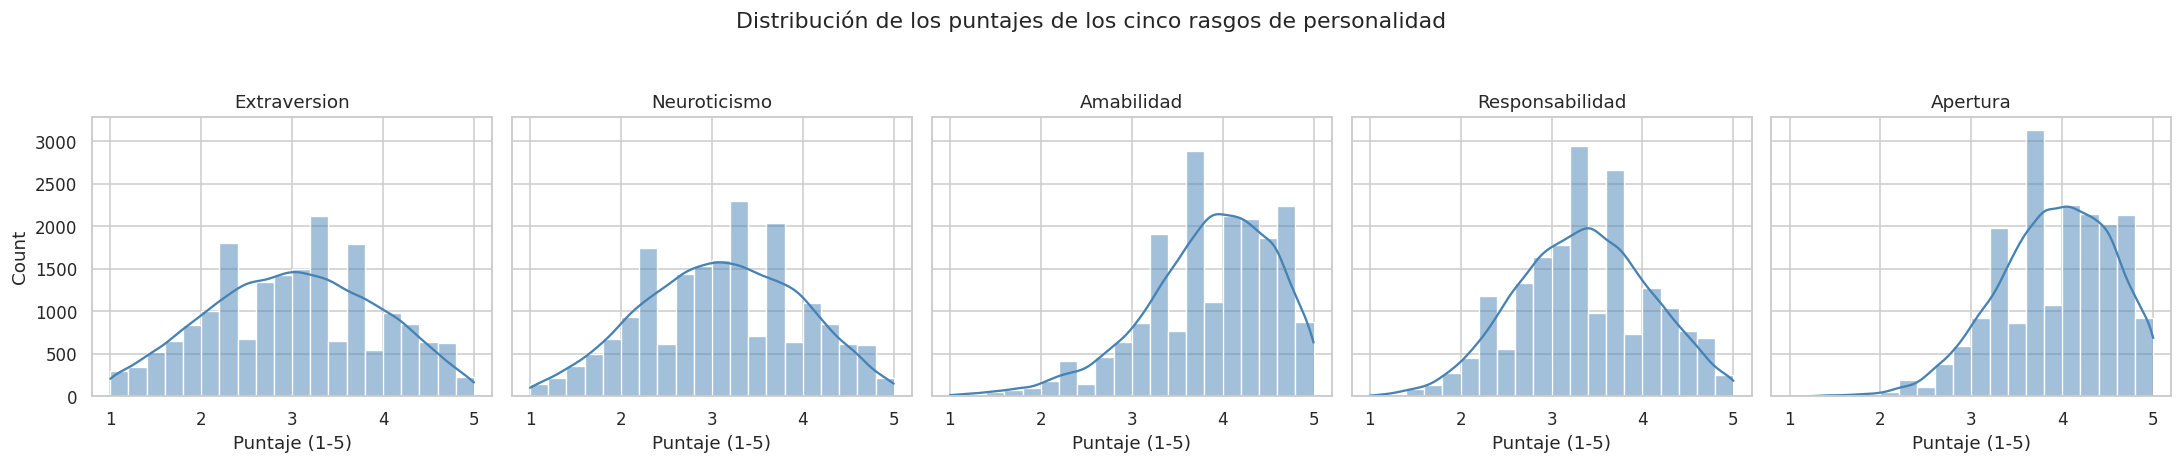

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, trait in zip(axes, trait_names):
    sns.histplot(df_scored[trait], bins=20, kde=True, ax=ax, color="steelblue")
    ax.set_title(trait)
    ax.set_xlabel("Puntaje (1-5)")
fig.suptitle("Distribución de los puntajes de los cinco rasgos de personalidad", y=1.05)
plt.tight_layout()
plt.show()

Extraversión y Neuroticismo se ven casi simétricas y centradas en 3, mientras que Amabilidad, Responsabilidad y Apertura están desplazadas hacia la derecha (sesgo hacia puntajes altos): la mayoría de la gente se autopercibe por encima del punto medio en esos tres rasgos.

### 7.2 Matriz de correlación entre rasgos (heatmap)

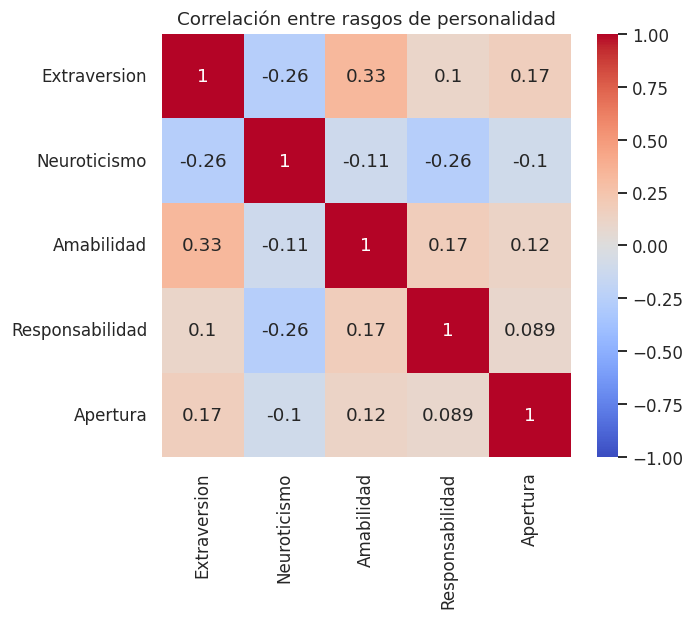

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_traits, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlación entre rasgos de personalidad")
plt.show()

Todas las correlaciones son de leves a moderadas (máximo 0.33), sin ningún par de rasgos redundante entre sí; Neuroticismo es el único que se relaciona negativamente con los otros cuatro, siendo Responsabilidad (-0.26) la relación negativa más fuerte.

### 7.3 Comparación de rasgos por género

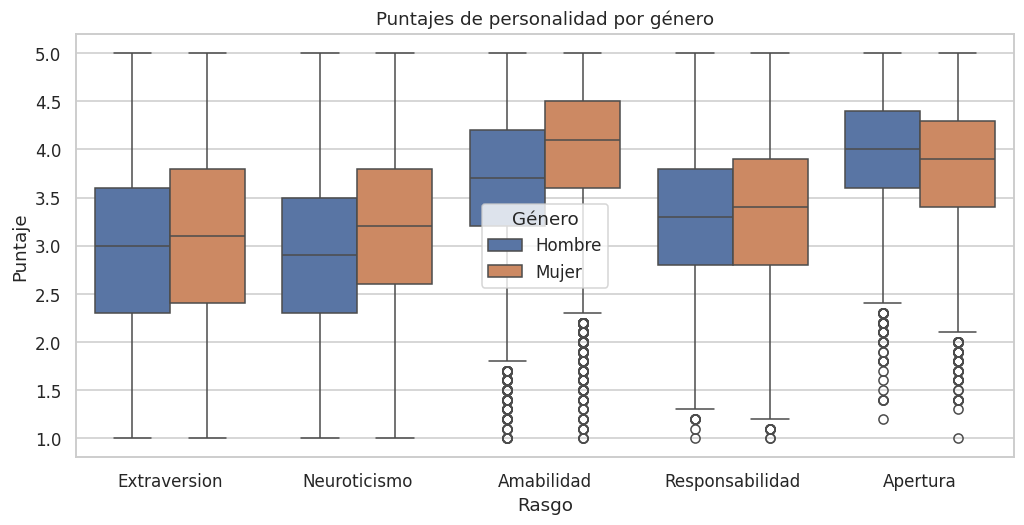

In [14]:
df_gender = df_scored[df_scored["gender"].isin([1, 2])].copy()
df_gender["gender"] = df_gender["gender"].map({1: "Hombre", 2: "Mujer"})
df_melt = df_gender.melt(id_vars="gender", value_vars=trait_names,
                          var_name="Rasgo", value_name="Puntaje")

plt.figure(figsize=(11, 5))
sns.boxplot(data=df_melt, x="Rasgo", y="Puntaje", hue="gender")
plt.title("Puntajes de personalidad por género")
plt.legend(title="Género")
plt.show()

Las mujeres puntúan más alto que los hombres en Extraversión, Neuroticismo, Amabilidad y Responsabilidad, mientras que en Apertura ocurre lo contrario (los hombres puntúan levemente más alto); la diferencia más notoria es en Neuroticismo.

### 7.4 Distribución de la edad de los participantes

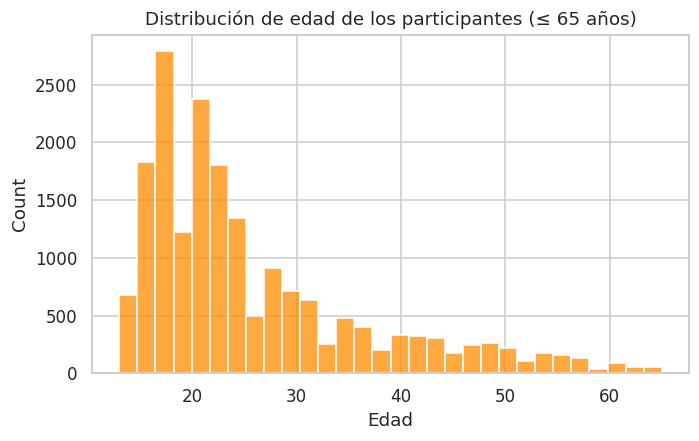

In [15]:
plt.figure(figsize=(7, 4))
sns.histplot(df_scored["age"], bins=30, color="darkorange")
plt.title("Distribución de edad de los participantes (≤ 65 años)")
plt.xlabel("Edad")
plt.show()

La muestra está fuertemente concentrada en participantes jóvenes (pico marcado entre 17 y 23 años) y decae de forma sostenida después de los 30, con muy pocos casos por encima de 50.

### 7.5 Participantes por país (top 10)

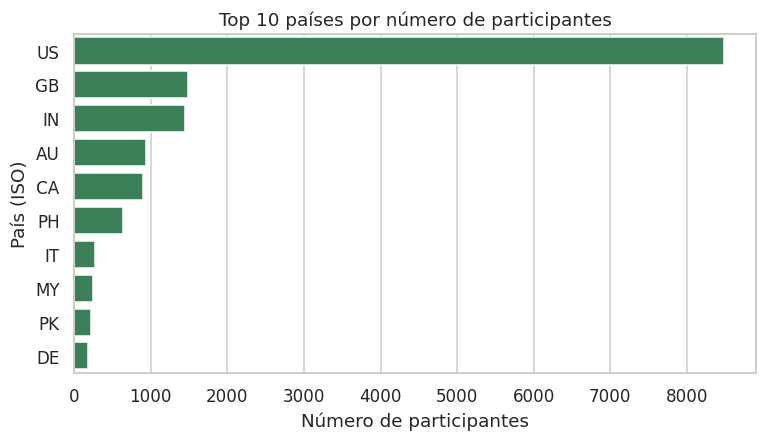

In [16]:
top_countries = df_scored["country"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_countries.values, y=top_countries.index, color="seagreen")
plt.title("Top 10 países por número de participantes")
plt.xlabel("Número de participantes")
plt.ylabel("País (ISO)")
plt.show()

Estados Unidos domina (más del doble que el resto de los países combinados), seguido de lejos por Reino Unido e India; el resto de los países del top 10 tienen una participación marginal en comparación.

## 8. Top 3 de variables de personalidad más representativas

Para decidir cuáles de los cinco rasgos son los **más representativos** del dataset combinamos tres criterios objetivos calculados arriba:

1. **Confiabilidad (Alpha de Cronbach):** un rasgo mal medido no es representativo aunque tenga datos, porque no sabemos si realmente refleja el rasgo.
2. **Variabilidad (desviación estándar):** un rasgo con muy poca dispersión aporta poco para diferenciar personas.
3. **Independencia (correlación promedio con los otros rasgos):** un rasgo muy correlacionado con otro es parcialmente redundante; uno con baja correlación aporta información única.

Construimos un ranking simple combinando estos tres criterios (todos normalizados 0-1).

In [17]:
ranking = pd.DataFrame({
    "alpha_cronbach": alphas,
    "desv_std": desc_stats["desv_std"],
    "correlacion_media_abs": corr_traits.abs().apply(lambda col: (col.sum() - 1) / (len(col) - 1)),
})

# Normalizamos cada criterio a 0-1
norm = pd.DataFrame(index=ranking.index)
norm["alpha_norm"] = (ranking["alpha_cronbach"] - ranking["alpha_cronbach"].min()) / (ranking["alpha_cronbach"].max() - ranking["alpha_cronbach"].min())
norm["std_norm"] = (ranking["desv_std"] - ranking["desv_std"].min()) / (ranking["desv_std"].max() - ranking["desv_std"].min())
norm["independencia_norm"] = 1 - (ranking["correlacion_media_abs"] - ranking["correlacion_media_abs"].min()) / (ranking["correlacion_media_abs"].max() - ranking["correlacion_media_abs"].min())

norm["score_final"] = norm.mean(axis=1)
ranking_final = pd.concat([ranking.round(3), norm.round(3)], axis=1).sort_values("score_final", ascending=False)
ranking_final

,alpha_cronbach,desv_std,correlacion_media_abs,alpha_norm,std_norm,independencia_norm,score_final
Extraversion,0.892,0.922,0.216,1.000,1.000,0.000,0.667
Neuroticismo,0.869,0.862,0.183,0.768,0.798,0.339,0.635
Responsabilidad,0.813,0.730,0.156,0.202,0.354,0.607,0.388
Amabilidad,0.832,0.715,0.184,0.394,0.303,0.329,0.342
Apertura,0.793,0.625,0.118,0.000,0.000,1.000,0.333


Con base en la tabla anterior, el **top 3** de rasgos de personalidad más representativos del dataset son los tres con mayor `score_final`:
- **Extraversion**
- **Neuroticismo**
- **Responsabilidad**

Ya que combinan:
  - alta consistencia interna (miden de forma confiable el rasgo),
  - suficiente variabilidad entre participantes (permiten diferenciar personas), y
  - baja redundancia con los demás rasgos (aportan información única al perfil de personalidad).

## 9. Análisis de Componentes Principales (PCA)

Trabajamos con los **50 ítems individuales** (no los 5 puntajes ya promediados) para ver si, a ese nivel de detalle, se puede **reducir la dimensionalidad** de los datos y qué variables resultan más representativas para un análisis posterior.

### 9.1 Estandarización de las variables

PCA es sensible a la escala/varianza de cada variable. Aunque los 50 ítems ya comparten la misma escala Likert (1-5), cada uno tiene su propia varianza, así que estandarizamos (media 0, desviación estándar 1) antes de aplicar PCA.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_clean[item_cols]  # ítems ya invertidos donde corresponde no es necesario para PCA (la varianza es la misma)
X = df_scored[item_cols]  # usamos los ítems ya re-codificados en el mismo sentido
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
print(f"Número total de componentes posibles: {len(var_ratio)} (= número de ítems originales)")

Número total de componentes posibles: 50 (= número de ítems originales)


### 9.2 Varianza explicada por componente

*Scree plot* (varianza explicada por cada componente) y varianza acumulada, con una línea de referencia en 90%.

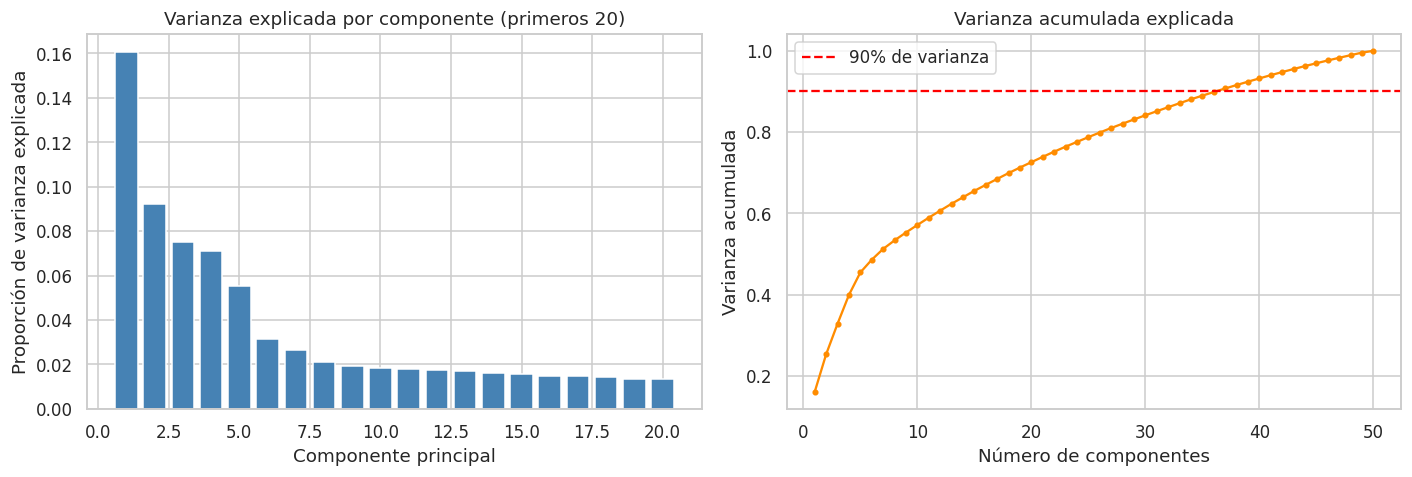

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, 21), var_ratio[:20], color="steelblue")
axes[0].set_title("Varianza explicada por componente (primeros 20)")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Proporción de varianza explicada")

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=3, color="darkorange")
axes[1].axhline(0.90, color="red", linestyle="--", label="90% de varianza")
axes[1].set_title("Varianza acumulada explicada")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

La caída de varianza es muy alta en el primer componente (16%) y luego decrece rápido y de forma gradual: no hay un "codo" claro después de los primeros 4-5 componentes, señal de que la información está repartida entre muchos ítems y no concentrada en pocos items dominantes.

### 9.3 ¿Cuántas variables/componentes se necesitan para explicar el 90% o más de los datos?

In [20]:
n_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)
n_5  = 5  # número de rasgos teóricos del modelo Big Five

print(f"Varianza explicada por los primeros {n_5} componentes (uno por rasgo teórico): {cum_var[n_5-1]*100:.1f}%")
print(f"Componentes necesarios para explicar >= 90% de la varianza: {n_90} (de {len(var_ratio)} ítems originales)")
print(f"Componentes necesarios para explicar >= 95% de la varianza: {n_95} (de {len(var_ratio)} ítems originales)")

Varianza explicada por los primeros 5 componentes (uno por rasgo teórico): 45.4%
Componentes necesarios para explicar >= 90% de la varianza: 37 (de 50 ítems originales)
Componentes necesarios para explicar >= 95% de la varianza: 43 (de 50 ítems originales)


Los primeros 5 componentes (uno por rasgo teórico) explican apenas 45.4% de la varianza total; para llegar a 90% hacen falta 37 de los 50 ítems originales, y 43 para 95%. Esto confirma que no existe una reducción fuerte de dimensionalidad: cada ítem individual aporta varianza propia que los demás ítems del mismo rasgo no comparten, así que PCA no logra "comprimir" la información en pocas variables si el objetivo es preservar casi toda la varianza original.

### 9.4 Variables representativas por componente

Para los primeros 5 componentes (los que, en teoría, deberían corresponder a los cinco rasgos de personalidad) identificamos qué ítems tienen mayor carga (en valor absoluto), es decir, cuáles son las variables más representativas de cada componente para un análisis posterior.

In [21]:
pca_5 = PCA(n_components=5)
scores_5 = pca_5.fit_transform(X_scaled)

loadings = pca_5.components_.T * np.sqrt(pca_5.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=item_cols, columns=[f"PC{i+1}" for i in range(5)])

for pc in loadings_df.columns:
    top5 = loadings_df[pc].abs().sort_values(ascending=False).head(5).index
    print(f"{pc} (variables más representativas)")
    print(loadings_df.loc[top5, pc].round(3), "\n")

PC1 (variables más representativas)
E3     0.711
E5     0.657
E7     0.627
E4     0.585
E10    0.572
Name: PC1, dtype: float64 

PC2 (variables más representativas)
N6    0.544
N8    0.535
N7    0.527
N1    0.490
N3    0.467
Name: PC2, dtype: float64 

PC3 (variables más representativas)
A4    0.479
C9    0.471
C7    0.446
A6    0.434
A9    0.429
Name: PC3, dtype: float64 

PC4 (variables más representativas)
O10    0.624
O1     0.623
O8     0.616
O5     0.563
O2     0.554
Name: PC4, dtype: float64 

PC5 (variables más representativas)
C9    0.411
C5    0.392
N9    0.376
C7    0.368
C1    0.352
Name: PC5, dtype: float64 



**PC1** y **PC2** recuperan de forma limpia dos de los cinco rasgos teóricos: Extraversión (E3, E5, E7, E4, E10) y Neuroticismo (N6, N8, N7, N1, N3) respectivamente.

**PC4** hace lo mismo con Apertura (O10, O1, O8, O5, O2).

**PC3** y **PC5**, en cambio, mezclan ítems de Amabilidad y Responsabilidad (A4, C9, C7, A6, A9 en PC3; C9, C5, N9, C7, C1 en PC5) en lugar de separarse en un componente propio para cada uno, lo que indica que estos dos rasgos comparten más varianza entre sí (menos independientes) que los otros tres.

### 9.5 Conclusión: ¿se puede reducir el número de variables a componentes?

PCA sí es útil para recuperar e interpretar la estructura teórica del Big Five (3 de 5 rasgos emergen limpiamente en los primeros componentes), pero no es útil como técnica de reducción fuerte de variables si lo que queremos es conservar mas del 90% de la información original, ya que para eso prácticamente se necesitarían casi todos los ítems.

## 10. Análisis de clustering (K-Means)

Usamos los **5 puntajes de personalidad** (Extraversión, Neuroticismo, Amabilidad, Responsabilidad, Apertura) en lugar de los 50 ítems individuales.

Estandarizamos los 5 puntajes antes de aplicar el algoritmo, ya que K-Means se basa en distancias euclidianas.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_traits = StandardScaler().fit_transform(df_scored[trait_names])
print("Forma de la matriz usada para clustering:", X_traits.shape)

Forma de la matriz usada para clustering: (18842, 5)


### 10.1 Clustering para k = 2, 3 y 5

Para cada valor de *k* mostramos el tamaño de cada clúster y señalamos cuál tiene menos datos.

In [23]:
for k in [2, 3, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_traits)
    sizes = pd.Series(labels).value_counts().sort_index()
    print(f"k = {k} ")
    print(sizes.rename("n_participantes"))
    print(f"Clúster con menos datos: clúster {sizes.idxmin()} ({sizes.min()} participantes, {sizes.min()/len(labels)*100:.1f}% del total)\n")

k = 2 
0    9323
1    9519
Name: n_participantes, dtype: int64
Clúster con menos datos: clúster 0 (9323 participantes, 49.5% del total)

k = 3 
0    5765
1    6712
2    6365
Name: n_participantes, dtype: int64
Clúster con menos datos: clúster 0 (5765 participantes, 30.6% del total)

k = 5 
0    4037
1    2664
2    3623
3    3629
4    4889
Name: n_participantes, dtype: int64
Clúster con menos datos: clúster 1 (2664 participantes, 14.1% del total)



**Conclusión:** en los tres casos (k=2, 3, 5) los clústeres quedan razonablemente balanceados: incluso con k=5, el clúster más chico conserva 14.1% de la muestra (2,664 participantes). El desbalance entre el clúster más grande y el más chico crece conforme aumenta k (49.5% del total con k=2, frente a 14.1% con k=5), lo cual es esperable porque al haber más grupos la muestra se reparte en porciones más finas — no es indicio de que algún valor de k sea "malo", solo de mayor granularidad.

### 10.2 ¿Cuántos clústeres recomendamos? (k = ?)

Para decidir el número de clústeres usamos dos criterios estándar sobre un rango de *k* de 2 a 8:

- **Método del codo** : inercia (suma de distancias al cuadrado dentro de cada clúster), buscamos el punto donde agregar más clústeres deja de reducir la inercia de forma importante.
- **Coeficiente de silueta**: qué tan bien separados y compactos quedan los clústeres (va de -1 a 1; más alto es mejor).

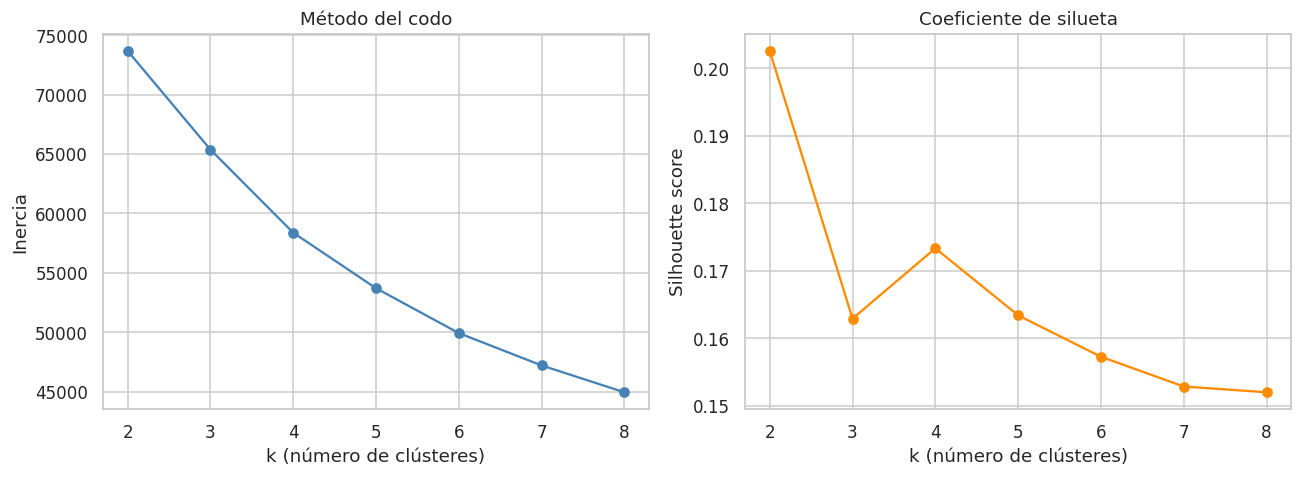

,k,inercia,silhouette
0,2,73677.8677,0.2026
1,3,65371.7379,0.1629
2,4,58383.7800,0.1734
3,5,53711.1059,0.1634
4,6,49935.4584,0.1573
5,7,47218.6385,0.1529
6,8,44958.5391,0.1520


In [24]:
ks = range(2, 9)
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_traits)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_traits, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(ks), inertias, marker="o", color="steelblue")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("k (número de clústeres)")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(ks), sils, marker="o", color="darkorange")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("k (número de clústeres)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(ks), "inercia": inertias, "silhouette": sils}).round(4)

**Recomendación :**

El coeficiente de silueta es en general **bajo** y decrece de forma suave conforme aumenta *k*, sin un salto brusco en ningún punto; la curva de inercia tampoco muestra un "codo" muy marcado.

Dicho esto, si hay que elegir un valor práctico de *k* :
- **k = 2** obtiene el silhouette score más alto de todo el rango, pero produce una segmentación muy general (básicamente "más vs. menos extrovertido").
- **k = 3**: es el primer punto donde la curva de inercia empieza a aplanarse y produce tres perfiles de personalidad mas interpretables sin romper demasiado la muestra en grupos muy pequeños.

Por lo tanto usaremos: **k = 3**.

### 10.3 Análisis descriptivo de los clústeres generados (k = 3)

Usamos k = 3 para describir los perfiles de personalidad resultantes.

In [25]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_scored["cluster"] = km_final.fit_predict(X_traits)

cluster_sizes = df_scored["cluster"].value_counts().sort_index()
print("Tamaño de cada clúster:")
print(cluster_sizes, "\n")
print("Porcentaje del total:")
print((cluster_sizes / len(df_scored) * 100).round(1))

Tamaño de cada clúster:
cluster
0    5765
1    6712
2    6365
Name: count, dtype: int64 

Porcentaje del total:
cluster
0    30.6
1    35.6
2    33.8
Name: count, dtype: float64


**Conclusión:** con k=3 los tres grupos quedan razonablemente equilibrados (30.6%, 35.6% y 33.8% del total), sin ningún clúster residual demasiado pequeño, una segmentación balanceada y práctica para el análisis descriptivo que sigue.

#### 10.3.1 Perfil de personalidad promedio por clúster

In [26]:
cluster_profile = df_scored.groupby("cluster")[trait_names].mean().round(2)
cluster_profile

,Extraversion,Neuroticismo,Amabilidad,Responsabilidad,Apertura
cluster,,,,,
0,3.13,3.66,4.05,2.92,4.19
1,3.56,2.42,4.21,3.84,4.07
2,2.33,3.30,3.27,3.21,3.49


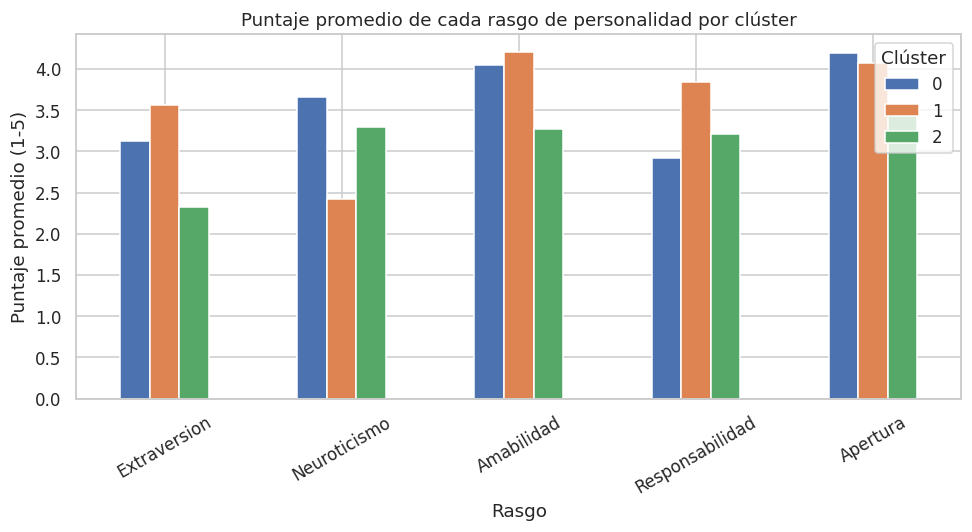

In [27]:
plt.figure(figsize=(9, 5))
cluster_profile.T.plot(kind="bar", ax=plt.gca())
plt.title("Puntaje promedio de cada rasgo de personalidad por clúster")
plt.ylabel("Puntaje promedio (1-5)")
plt.xlabel("Rasgo")
plt.xticks(rotation=30)
plt.legend(title="Clúster")
plt.tight_layout()
plt.show()

**Conclusión:** los tres clústeres muestran perfiles de personalidad claramente distintos:
- **Clúster 1 (35.6% de la muestra):** el más "estable/extrovertido" — mayor Extraversión (3.56) y Responsabilidad (3.84), y el menor Neuroticismo (2.42) de los tres.
- **Clúster 0 (30.6%):** perfil "ansioso/abierto" — el mayor Neuroticismo (3.66) y Apertura (4.19), pero la menor Responsabilidad (2.92).
- **Clúster 2 (33.8%):** perfil "reservado" — el más bajo en casi todos los rasgos, en particular Extraversión (2.33) y Amabilidad (3.27).

Estas diferencias confirman que la segmentación con k=3 sí separa perfiles psicológicamente interpretables, aunque, como ya vimos en el silhouette score, los límites entre grupos no son totalmente nítidos.

#### 10.3.2 Visualización de los clústeres en 2D (usando los 2 primeros componentes de PCA)

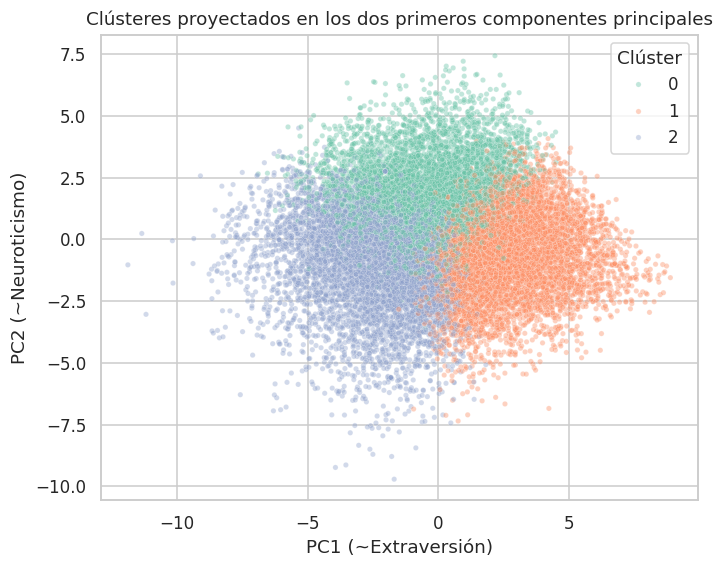

In [28]:
scores_2d = pca_5.transform(X_scaled)[:, :2]

plt.figure(figsize=(7, 5.5))
sns.scatterplot(x=scores_2d[:, 0], y=scores_2d[:, 1], hue=df_scored["cluster"].values,
                 palette="Set2", alpha=0.4, s=12, legend="full")
plt.title("Clústeres proyectados en los dos primeros componentes principales")
plt.xlabel("PC1 (~Extraversión)")
plt.ylabel("PC2 (~Neuroticismo)")
plt.legend(title="Clúster")
plt.show()

**Conclusión:** en la proyección 2D los tres grupos se distinguen sobre todo a lo largo del eje de Extraversión (PC1): el clúster "reservado" se ubica más hacia la izquierda (baja extraversión) y el clúster "estable/extrovertido" más hacia la derecha. Sin embargo, los tres grupos se sobreponen bastante entre sí, sin fronteras nítidas — consistente con el silhouette score bajo obtenido en la sección 10.2: los clústeres capturan una tendencia real, pero no representan grupos completamente separados.

#### 10.3.3 Perfil demográfico por clúster (edad y género)

In [29]:
demo_by_cluster = df_scored.groupby("cluster").agg(
    edad_promedio=("age", "mean"),
    n=("age", "size"),
)
demo_by_cluster["edad_promedio"] = demo_by_cluster["edad_promedio"].round(1)

gender_by_cluster = pd.crosstab(df_scored["cluster"], df_scored["gender"].map({1: "Hombre", 2: "Mujer", 3: "Otro"}),
                                 normalize="index").mul(100).round(1)

print("Edad promedio y tamaño por clúster:")
print(demo_by_cluster, "\n")
print("Distribución de género por clúster (%):")
print(gender_by_cluster)

Edad promedio y tamaño por clúster:
         edad_promedio     n
cluster                     
0                 24.7  5765
1                 28.9  6712
2                 23.9  6365 

Distribución de género por clúster (%):
gender   Hombre  Mujer  Otro
cluster                     
0          33.7   65.7   0.6
1          39.2   60.6   0.2
2          42.7   56.6   0.7


**Conclusión:** las diferencias de edad (23.9 a 28.9 años) y de género (56.6%-65.7% mujeres) entre los tres clústeres son pequeñas en comparación con las diferencias de personalidad observadas en 10.3.1. Esto sugiere que la segmentación refleja principalmente diferencias de **personalidad** y no está simplemente separando a los participantes por edad o género.

## 11. Conclusión final

- **Limpieza de datos:** partiendo de 19,726 registros, se recalcularon 73 edades capturadas erróneamente como año de nacimiento y se eliminaron 884 registros por ítems sin responder, edad fuera de rango, país inválido o variables demográficas faltantes/inválidas, quedando **18,842 registros finales** para el análisis.
- **Estadísticos descriptivos:** los cinco rasgos muestran consistencia interna aceptable a alta (Alpha de Cronbach > 0.79) y correlaciones bajas a moderadas entre sí, validando que se comportan como dimensiones de personalidad razonablemente independientes.
- **Top 3 de variables más representativas:** Extraversión, Neuroticismo y Responsabilidad, por combinar alta confiabilidad, buena variabilidad entre participantes y baja redundancia con los demás rasgos.
- **PCA:** permite recuperar de forma clara 3 de los 5 rasgos teóricos (Extraversión, Neuroticismo y Apertura) en sus primeros componentes, pero no logra una reducción fuerte de variables: se necesitan 37 de los 50 ítems originales para explicar el 90% de la varianza, ya que cada ítem aporta variación propia que no comparte con los demás de su mismo rasgo.
- **Clustering:** los datos de personalidad se comportan más como un continuo que como categorías discretas (silhouette bajo en todo el rango de k evaluado), pero al forzar una segmentación con k=3 se obtienen tres perfiles interpretables "estable/extrovertido", "ansioso/abierto" y "reservado" que se diferencian sobre todo por personalidad y no por edad o género.
- **Conclusión general:** el dataset Big Five, ya limpio, respalda razonablemente bien la estructura teórica del modelo (cinco rasgos con consistencia interna aceptable e independencia relativa entre sí). Tanto el PCA como el clustering coinciden, sin embargo, en que la personalidad al menos en estos datos se comporta más como dimensiones continuas y superpuestas que como categorías separables.